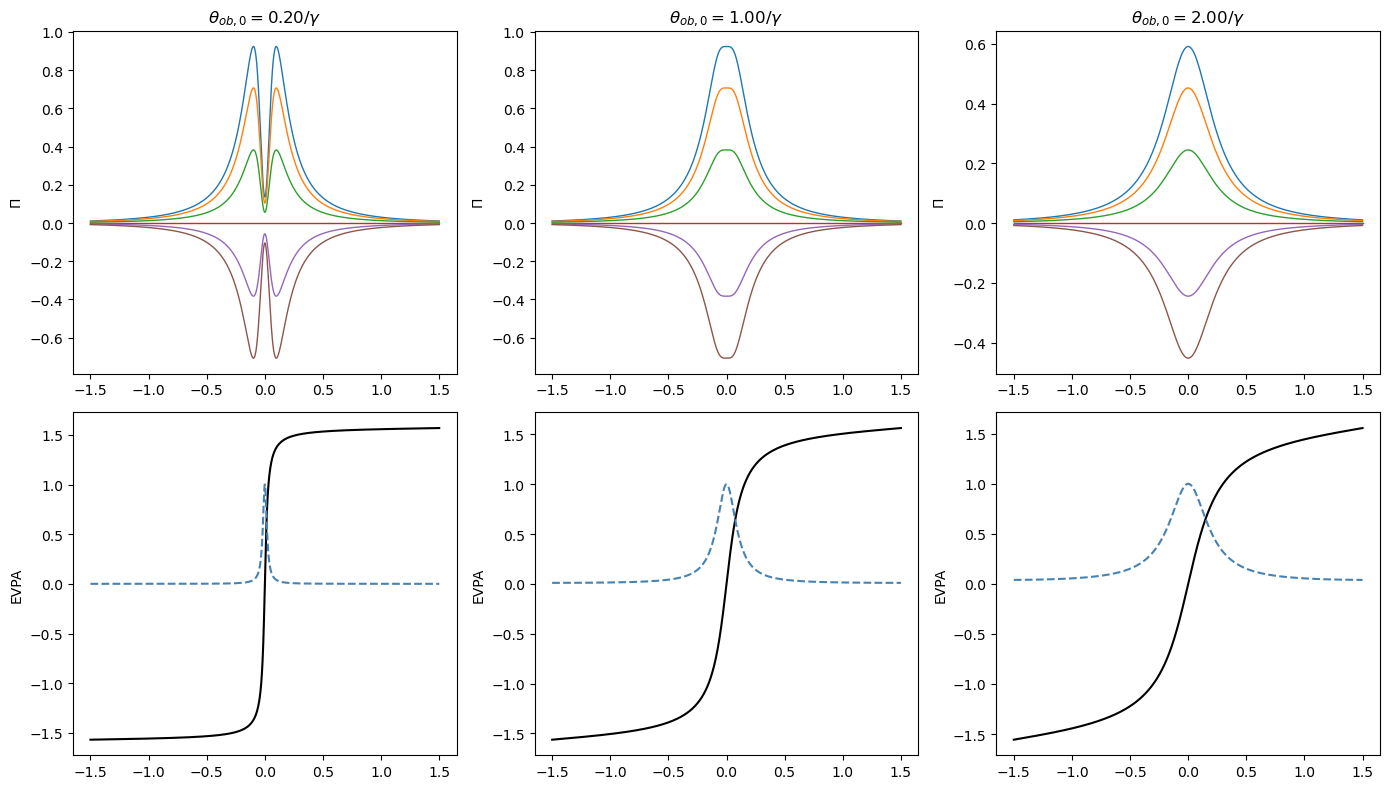

In [1]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 10.0
beta = np.sqrt(1 - 1/gamma**2)

theta0_values = [1/(5*gamma),1/gamma,2/gamma]

pitch_angles = [
    np.pi/16,
    np.pi/8,
    3*np.pi/16,
    np.pi/4,
    5*np.pi/16,
    3*np.pi/8
]

phi = np.linspace(-1.5,1.5,1000)

def theta_obs(phi,theta0):

    c=np.cos(theta0)*np.cos(phi)
    c=np.clip(c,-1,1)

    return np.arccos(c)


def PA(phi,theta0):

    s=np.sin(phi)

    d=np.sqrt(
        1-
        np.cos(theta0)**2*
        np.cos(phi)**2
    )

    x=s/d

    x=np.clip(x,-1,1)

    return np.arcsin(x)


def dPA(phi,theta0):

    num=np.sin(theta0)

    den=(
        1-
        np.cos(phi)**2*
        np.cos(theta0)**2
    )

    return num/den

def jet_polarization(theta,psi):

    # observer angle in comoving frame

    cos_thp=(np.cos(theta)-beta) / \
            (1-beta*np.cos(theta))

    thp=np.arccos(
        np.clip(cos_thp,-1,1)
    )

    sin2=np.sin(thp)**2

    Pi=np.cos(2*psi)*sin2

    return Pi


fig,ax=plt.subplots(
    2,
    3,
    figsize=(14,8)
)

for j,theta0 in enumerate(theta0_values):

    th=theta_obs(phi,theta0)

    for psi in pitch_angles:

        P=jet_polarization(th,psi)

        ax[0,j].plot(phi,P,lw=1)

    pa=PA(phi,theta0)

    rate=dPA(phi,theta0)

    rate/=rate.max()

    ax[1,j].plot(phi,pa,color='black')

    ax[1,j].plot(
        phi,
        rate,
        '--',
        color='steelblue'
    )

    ax[0,j].set_title(
        r'$\theta_{ob,0}=%.2f/\gamma$'
        %(theta0*gamma)
    )

    ax[0,j].set_ylabel(r'$\Pi$')
    ax[1,j].set_ylabel('EVPA')

plt.tight_layout()

plt.show()